<a href="https://colab.research.google.com/github/anchalsinha-0411/RNN-LSTM-BILSTM/blob/main/RNN_LSTM_BILSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/dataset/fake_news(z).zip",compression='zip')

NameError: name 'pd' is not defined

In [ ]:
df.head()df.head()

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1


In [ ]:
df['text'][0]

'House Dem Aide: We Didn’t Even See Comey’s Letter Until Jason Chaffetz Tweeted It By Darrell Lucus on October 30, 2016 Subscribe Jason Chaffetz on the stump in American Fork, Utah ( image courtesy Michael Jolley, available under a Creative Commons-BY license) \nWith apologies to Keith Olbermann, there is no doubt who the Worst Person in The World is this week–FBI Director James Comey. But according to a House Democratic aide, it looks like we also know who the second-worst person is as well. It turns out that when Comey sent his now-infamous letter announcing that the FBI was looking into emails that may be related to Hillary Clinton’s email server, the ranking Democrats on the relevant committees didn’t hear about it from Comey. They found out via a tweet from one of the Republican committee chairmen. \nAs we now know, Comey notified the Republican chairmen and Democratic ranking members of the House Intelligence, Judiciary, and Oversight committees that his agency was reviewing emai

In [ ]:
df['text'][1]

'Ever get the feeling your life circles the roundabout rather than heads in a straight line toward the intended destination? [Hillary Clinton remains the big woman on campus in leafy, liberal Wellesley, Massachusetts. Everywhere else votes her most likely to don her inauguration dress for the remainder of her days the way Miss Havisham forever wore that wedding dress.  Speaking of Great Expectations, Hillary Rodham overflowed with them 48 years ago when she first addressed a Wellesley graduating class. The president of the college informed those gathered in 1969 that the students needed “no debate so far as I could ascertain as to who their spokesman was to be” (kind of the like the Democratic primaries in 2016 minus the   terms unknown then even at a Seven Sisters school). “I am very glad that Miss Adams made it clear that what I am speaking for today is all of us —  the 400 of us,” Miss Rodham told her classmates. After appointing herself Edger Bergen to the Charlie McCarthys and Mor

In [ ]:
###Drop Nan Values
df=df.dropna()


In [ ]:
## Get the Independent Features
X=df.drop('label',axis=1)
#print(X)

In [ ]:
## Get the Dependent features
y=df['label']

In [ ]:
X.shape

(18285, 4)

In [ ]:
y.shape

(18285,)

In [ ]:
import tensorflow as tf

In [ ]:
tf.__version__

'2.18.0'

In [ ]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot

from tensorflow.keras.layers import SimpleRNN  #implementation of RNN
from tensorflow.keras.layers import LSTM       #implementation of LSTM
from tensorflow.keras.layers import Bidirectional
#from tensorflow.keras.layers import B
from tensorflow.keras.layers import Dense

In [ ]:
### Vocabulary size
voc_size=5000

### Onehot Representation

In [ ]:
messages=X.copy()

In [ ]:
messages['title'][1]

'FLYNN: Hillary Clinton, Big Woman on Campus - Breitbart'

In [ ]:
messages.reset_index(inplace=True)

In [ ]:
import nltk
import re
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
### Dataset Preprocessing
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
corpus = []
for i in range(0, len(messages)):
    #print(i)
    review = re.sub('[^a-zA-Z]', ' ', messages['title'][i])
    review = review.lower()
    review = review.split()

    review = [ps.stem(word) for word in review if not word in stopwords.words('english')]

    review = ' '.join(review)
    corpus.append(review)

In [ ]:
corpus[1]

'flynn hillari clinton big woman campu breitbart'

In [ ]:
onehot_repr=[one_hot(words,voc_size)for words in corpus]
onehot_repr

[[633, 4335, 3823, 862, 27, 687, 4472, 4071, 3354, 3437],
 [4662, 2467, 1680, 21, 2263, 1006, 3967],
 [1, 4882, 1076, 154],
 [2294, 3863, 2293, 2620, 2334, 3847],
 [2862, 2263, 4095, 147, 3682, 3795, 2263, 4648, 4548, 3723],
 [1726,
  1117,
  2823,
  502,
  627,
  145,
  4473,
  4334,
  3083,
  4135,
  3435,
  1471,
  1591,
  1467,
  3967],
 [367, 617, 3218, 3708, 1949, 2254, 1678, 3999, 3347, 2110, 781],
 [1527, 436, 1304, 3587, 4749, 2076, 145, 4696, 3347, 2110, 781],
 [3904, 2843, 344, 4772, 3576, 329, 3051, 3557, 145, 1214],
 [4153, 120, 4930, 1712, 2278, 1883, 632, 3163],
 [2773, 2128, 3647, 2093, 572, 3171, 813, 26, 3606, 884, 2899],
 [2620, 4050, 27, 329, 145, 4749],
 [4865, 164, 3649, 4726, 1840, 4825, 369, 2306, 4704],
 [4600, 2853, 4207, 1820, 3602, 3848, 3987, 3347, 2110, 781],
 [90, 2036, 679, 2997, 3256, 3347, 2110, 781],
 [501, 139, 2472, 2199, 2839, 3357, 2464, 4303, 754, 2493],
 [1332, 2604, 2467],
 [7, 4237, 2767, 2386, 145, 4011, 3209, 3967],
 [336, 397, 1680, 2087, 8

### Embedding Representation

In [ ]:
sent_length=20
embedded_docs=pad_sequences(onehot_repr,padding='pre',maxlen=sent_length)
print(embedded_docs)

[[   0    0    0 ... 4071 3354 3437]
 [   0    0    0 ... 2263 1006 3967]
 [   0    0    0 ... 4882 1076  154]
 ...
 [   0    0    0 ... 3347 2110  781]
 [   0    0    0 ... 3285 2037  524]
 [   0    0    0 ... 4656  215 3394]]


In [ ]:
embedded_docs[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,  633,
       4335, 3823,  862,   27,  687, 4472, 4071, 3354, 3437], dtype=int32)

In [ ]:
## Creating model
embedding_vector_features=40
model1=Sequential()
model1.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))

#model1.add(SimpleRNN(100))
model1.add(SimpleRNN(100))
model1.add(Dense(1,activation='sigmoid'))
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print(model1.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
len(embedded_docs),y.shape

(18285, (18285,))

In [ ]:
import numpy as np
X_final=np.array(embedded_docs)
y_final=np.array(y)

In [ ]:
X_final.shape,y_final.shape

((18285, 20), (18285,))

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.33, random_state=42)

### Model Training

In [ ]:
### Finally Training
model1.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8276 - loss: 0.3668 - val_accuracy: 0.9153 - val_loss: 0.2035
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9524 - loss: 0.1197 - val_accuracy: 0.9153 - val_loss: 0.2471
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9906 - loss: 0.0330 - val_accuracy: 0.9100 - val_loss: 0.2993
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9978 - loss: 0.0089 - val_accuracy: 0.9135 - val_loss: 0.3564
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0022 - val_accuracy: 0.9137 - val_loss: 0.4028
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 1.0000 - loss: 5.4956e-04 - val_accuracy: 0.9104 - val_loss: 0.4117
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 2.8280e-04 - val_accuracy: 0.9118 - val_loss: 0.4370
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 1.6971e-04 - val

In [ ]:
y_pred=model1.predict(X_test)

189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
y_pred_binary=[1 if prob>=0.5 else 0 for prob in y_pred]

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix

accuracy_score(y_test,y_pred_binary)

0.9106876553438277

<Axes: title={'center': 'model-1 simple RNN'}>

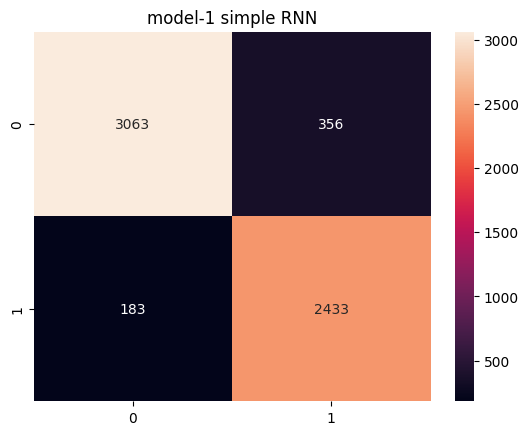

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,y_pred_binary)
plt.title("model-1 simple RNN")
sns.heatmap(cm,annot= True,fmt='d')

In [ ]:
comp1=pd.DataFrame(y_test,y_pred_binary)
comp1.head(10)

,0
1,1
0,0
0,0
0,0
1,1
1,1
1,0
1,1
1,1
1,1


### Adding Dropout

In [ ]:
## Creating model
embedding_vector_features=40
model2=Sequential()
model2.add(Embedding(voc_size,embedding_vector_features,input_length=sent_length))
model2.add(LSTM(100))
model2.add(Dense(1,activation='sigmoid'))
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print(model2.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8003 - loss: 0.4224 - val_accuracy: 0.9158 - val_loss: 0.1964
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9389 - loss: 0.1485 - val_accuracy: 0.9191 - val_loss: 0.2074
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9643 - loss: 0.0969 - val_accuracy: 0.9216 - val_loss: 0.2071
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9771 - loss: 0.0676 - val_accuracy: 0.9160 - val_loss: 0.2378
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9895 - loss: 0.0340 - val_accuracy: 0.9147 - val_loss: 0.2994
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9935 - loss: 0.0202 - val_accuracy: 0.9171 - val_loss: 0.3653
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.9036 - val_loss: 0.5267
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 

In [ ]:
y_pred2=model2.predict(X_test)


189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:

y_pred_binary2=[1 if prob>=0.5 else 0 for prob in y_pred2]

In [ ]:
accuracy_score2=accuracy_score(y_test,y_pred_binary2)
accuracy_score2

0.9090306545153273

<Axes: title={'center': 'model 2 lstm'}>

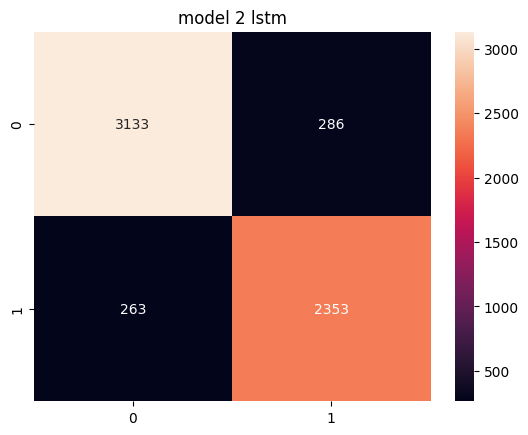

In [ ]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred_binary2)
plt.title("model 2 lstm")
sns.heatmap(cm,annot= True,fmt='d')

In [ ]:
from tensorflow.keras.layers import Dropout
## Creating model
0
model3 = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=300),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])
model3.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print(model3.summary())

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model3.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8007 - loss: 0.3910 - val_accuracy: 0.9183 - val_loss: 0.2013
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9531 - loss: 0.1269 - val_accuracy: 0.8996 - val_loss: 0.2355
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9700 - loss: 0.0832 - val_accuracy: 0.9165 - val_loss: 0.2220
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9841 - loss: 0.0509 - val_accuracy: 0.9185 - val_loss: 0.2922
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9905 - loss: 0.0323 - val_accuracy: 0.9132 - val_loss: 0.3676
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9964 - loss: 0.0144 - val_accuracy: 0.9142 - val_loss: 0.4457
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9958 - loss: 0.0136 - val_accuracy: 0.9080 - val_loss: 0.5217
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9983 - loss: 0.0068 - val_acc

In [ ]:
y_pred3=model3.predict(X_test)

189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [ ]:
y_pred_binary3=[1 if prob>=0.5 else 0 for prob in y_pred3]

In [ ]:
accuracy_score(y_test,y_pred_binary3)

0.9121789560894781

<Axes: title={'center': 'model 3 bidirectional lstm with dropout'}>

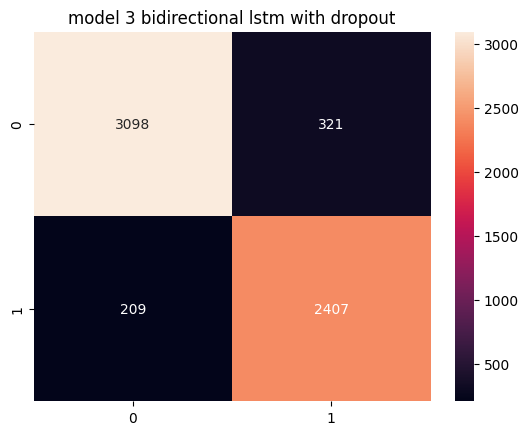

In [ ]:
import seaborn as sns
cm=confusion_matrix(y_test,y_pred_binary3)
plt.title("model 3 bidirectional lstm with dropout")
sns.heatmap(cm,annot= True,fmt='d')